In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.manifold import TSNE
from scipy.spatial.distance import pdist
from sklearn.metrics import pairwise_distances
import numpy as np

In [64]:
# Load data
df = pd.read_csv("../Data/final_cleaned_dataset.csv", index_col=0)

# Separate country info
country_info = df[['CountryCode', 'CountryName']]
df_features = df.drop(columns=['CountryCode', 'CountryName'])
print("Colums:", df_features.columns.tolist())

Colums: ['TourismEmploymentPer1000', 'FoodEmploymentPer1000', 'TourismGDPPercentage', 'BusinessToPersonalRatio', 'AverageStayDays', 'InboundArrivalsPer1000', 'DomesticTouristsPer1000', 'InboundToOutboundRatio', 'QualityOfLifeIndex', 'ReverseTrafficInefficiencyIndex', 'ReverseTrafficIndex', 'CostOfLivingIndex', 'GroceriesCostIndex', 'RestaurantPriceIndex', 'SafetyIndex', 'HealthCareIndex', 'ClimateIndex', 'ReverseTrafficTimeIndexMinutes', 'ReversePollutionIndex']


In [65]:
#Find best number of clusters using silhouette scores and elbow method
range_n_clusters = range(2, 11) #between 2 and 11 clusters
inertia = []
silhouette_scores = []

In [66]:
for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(df_features)
    silhouette_avg = silhouette_score(df_features, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    inertia.append(kmeans.inertia_)
    print(f"Number of clusters: {n_clusters}, Silhouette score: {silhouette_avg:.3f}, Inertia: {kmeans.inertia_:.3f}")

Number of clusters: 2, Silhouette score: 0.265, Inertia: 305128.762
Number of clusters: 3, Silhouette score: 0.235, Inertia: 281470.792
Number of clusters: 4, Silhouette score: 0.181, Inertia: 243997.631
Number of clusters: 5, Silhouette score: 0.169, Inertia: 207152.031
Number of clusters: 6, Silhouette score: 0.159, Inertia: 202650.174
Number of clusters: 7, Silhouette score: 0.145, Inertia: 186706.059
Number of clusters: 8, Silhouette score: 0.158, Inertia: 178067.369
Number of clusters: 9, Silhouette score: 0.153, Inertia: 167109.483
Number of clusters: 10, Silhouette score: 0.133, Inertia: 156754.970


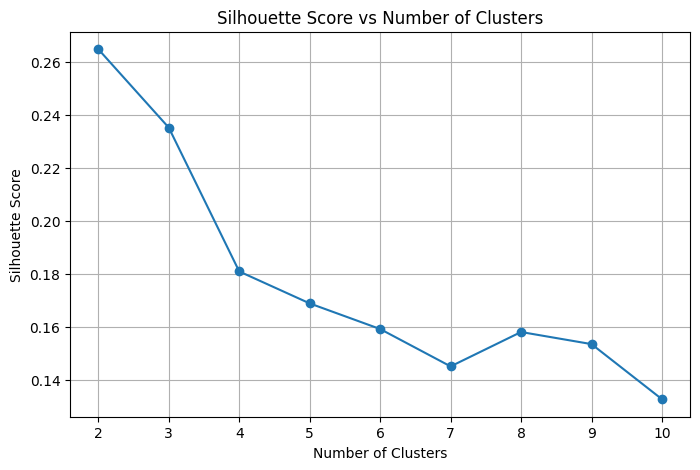

In [67]:
# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(range_n_clusters, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.grid(True)
plt.show()

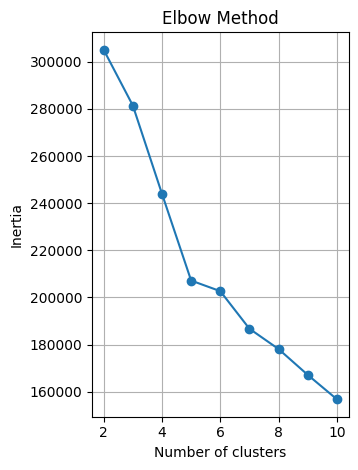

In [68]:
plt.subplot(1, 2, 1)
plt.plot(range_n_clusters, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.tight_layout()
plt.grid(True)
plt.show()

In [69]:
#Choose the best k (based on max silhouette score)
best_k = range_n_clusters[silhouette_scores.index(max(silhouette_scores))]
best_k_elbow = range_n_clusters[inertia.index(max(inertia))]
print(f"Best number of clusters based on Silhouette scores: {best_k}")
print(f"Best number of clusters based on Elbow method: {best_k_elbow}")

Best number of clusters based on Silhouette scores: 2
Best number of clusters based on Elbow method: 2


Even though the best number of clusters is 2, we can consider also k=3, since the values are quite close.

In [70]:
#Apply KMeans with best_k
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(df_features)

In [71]:
# Create final dataframe with cluster assignments
df_clustered = country_info.copy()
df_clustered["Cluster"] = cluster_labels
df_clustered_final = pd.concat([country_info, pd.Series(cluster_labels, name="Cluster")], axis=1)

In [72]:
# Show clusters and countries
cluster_counts = df_clustered_final['Cluster'].value_counts()
print("Number of countries in each cluster:")
print(cluster_counts)
 
#Group countries by cluster and display all
k2_grouped = df_clustered_final.groupby('Cluster')['CountryName'].apply(list).reset_index()
k2_grouped.columns = ['Cluster', 'Countries']
print("\nCountries grouped by cluster:")
for _, row in k2_grouped.iterrows():
    print(f"\nCluster {row['Cluster']} - {len(row['Countries'])} countries:")
    print(', '.join(row['Countries']))

Number of countries in each cluster:
Cluster
0    50
1    39
Name: count, dtype: int64

Countries grouped by cluster:

Cluster 0 - 50 countries:
Albania, Algeria, Angola, Argentina, Azerbaijan, Belarus, Belize, Brazil, Brunei, Cameroon, Chile, Costa Rica, Dominican Republic, Ecuador, Egypt, El Salvador, Georgia, Ghana, Honduras, India, Indonesia, Jordan, Kazakhstan, Kyrgyzstan, Lebanon, Madagascar, Malaysia, Mauritius, Mexico, Moldova, Mongolia, Morocco, Mozambique, Namibia, Nicaragua, Nigeria, Palestine, Panama, Paraguay, Philippines, Romania, Russia, Serbia, South Africa, Sri Lanka, Thailand, Turkey, Uganda, Uzbekistan, Zambia

Cluster 1 - 39 countries:
Australia, Austria, Bahrain, Belgium, Cayman Islands, Croatia, Cyprus, Denmark, Estonia, Finland, France, Germany, Greece, Hungary, Iceland, Israel, Japan, Latvia, Lithuania, Monaco, Montenegro, Netherlands, New Zealand, Norway, Poland, Portugal, Puerto Rico, Saudi Arabia, Slovakia, Slovenia, South Korea, Spain, Sweden, Switzerland, T

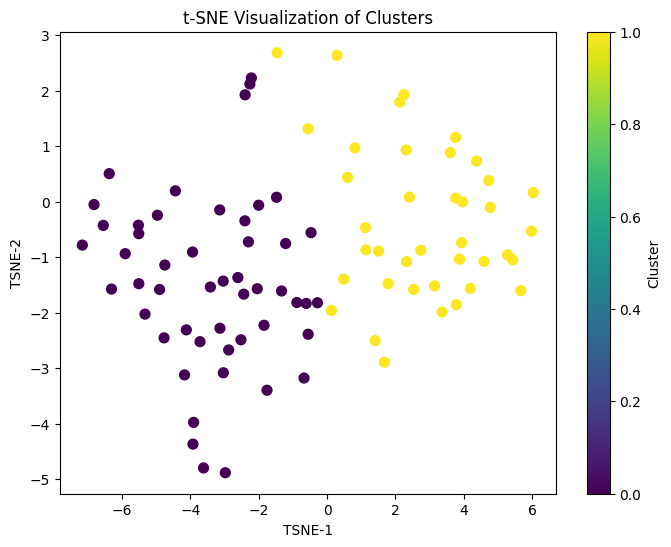

In [73]:
# Apply t-SNE for 2D projection

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(df_features)
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels, cmap='viridis', s=50)
plt.title('t-SNE Visualization of Clusters')
plt.xlabel('TSNE-1')
plt.ylabel('TSNE-2')
plt.colorbar(label='Cluster')
plt.show()
 

Cluster 0 (Navy):

* Countries in this group are likely more similar to each other.
* Might include emerging economies, poor countries with low cost of living

Cluster 1 (Yellow):

* More scattered and spread out.
* Indicates higher internal variation between countries in this cluster.
* This could represent more developed economies (e.g., high infrastructure, better scores in safety, healthcare, tourism).

In [74]:
#Cluster Evaluation
def dunn_index(X, labels):
    unique_cluster_labels = np.unique(labels)
    n_clusters = len(unique_cluster_labels)
    # Compute intra-cluster distances (max within each cluster)
    intra_dists = []
    for k in unique_cluster_labels:
        cluster_points = X[labels == k]
        if len(cluster_points) > 1:
            distances = pairwise_distances(cluster_points)
            intra_dists.append(np.max(distances))
        else:
            intra_dists.append(0)
 
    max_intra = np.max(intra_dists)
 
    # Compute inter-cluster distances (min between each pair of clusters)
    inter_dists = []
    for i in range(n_clusters):
        for j in range(i + 1, n_clusters):
            cluster_i = X[labels == unique_cluster_labels[i]]
            cluster_j = X[labels == unique_cluster_labels[j]]
            distances = pairwise_distances(cluster_i, cluster_j)
            inter_dists.append(np.min(distances))
 
    min_inter = np.min(inter_dists)
 
    return min_inter / max_intra if max_intra != 0 else 0
 
silhouette = silhouette_score(df_features, cluster_labels)
dunn = dunn_index(df_features, cluster_labels)
davies = davies_bouldin_score(df_features, cluster_labels)
calinski = calinski_harabasz_score(df_features, cluster_labels)
 
 
print(f"Silhouette Score: {silhouette:.4f}")
print(f"Dunn Index: {dunn:.4f}")
print(f"Davies-Bouldin Index: {davies:.4f}")
print(f"Calinski-Harabasz Index: {calinski:.4f}")

Silhouette Score: 0.2566
Dunn Index: 0.0897
Davies-Bouldin Index: 1.4333
Calinski-Harabasz Index: 35.4790


Interpretation of evaluation measures:

* Silhouette Score: Low to moderate clustering quality. It indicates that clusters are somewhat overlapping.
* Dunn Index: Very low. This suggests clusters are not well separated or some are too spread out. It hints at overlapping or elongated clusters.
* Davies-Bouldin Index: Acceptable but not great. Lower is better, and anything above 1.0 shows clusters are not well isolated.
* Calinski-Harabasz Index: Modest separation. Higher values (100+) typically indicate very distinct clusters. This value is okay but not strong.

In [75]:
# Add labels back to data
clustered_df = pd.concat([country_info, pd.DataFrame(df_features), pd.Series(cluster_labels, name='Cluster')], axis=1)
clustered_df.to_csv('kmeans_2_clusters.csv')

# Run kMeans for 3 clusters

In [76]:
#Apply KMeans with k=3
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(df_features)

df_clustered = country_info.copy()
df_clustered["Cluster"] = cluster_labels
df_clustered_final = pd.concat([country_info, pd.Series(cluster_labels, name="Cluster")], axis=1)
# 4. Show clusters and countries
cluster_counts = df_clustered_final['Cluster'].value_counts()
print("Number of countries in each cluster:")
print(cluster_counts)

Number of countries in each cluster:
Cluster
0    41
1    33
2    15
Name: count, dtype: int64


In [77]:
k2_grouped = df_clustered_final.groupby('Cluster')['CountryName'].apply(list).reset_index()
k2_grouped.columns = ['Cluster', 'Countries']
print("\nCountries grouped by cluster:")
for _, row in k2_grouped.iterrows():
    print(f"\nCluster {row['Cluster']} - {len(row['Countries'])} countries:")
    print(', '.join(row['Countries']))
k2_grouped = df_clustered_final.groupby('Cluster')['CountryName'].apply(list).reset_index()
k2_grouped.columns = ['Cluster', 'Countries']
print("\nCountries grouped by cluster:")
for _, row in k2_grouped.iterrows():
    print(f"\nCluster {row['Cluster']} - {len(row['Countries'])} countries:")
    print(', '.join(row['Countries']))


Countries grouped by cluster:

Cluster 0 - 41 countries:
Albania, Algeria, Argentina, Azerbaijan, Bahrain, Belarus, Belize, Brazil, Brunei, Chile, Ecuador, Georgia, Hungary, Indonesia, Jordan, Kazakhstan, Kyrgyzstan, Lebanon, Malaysia, Mauritius, Mexico, Moldova, Morocco, Mozambique, Namibia, Nicaragua, Palestine, Panama, Paraguay, Poland, Romania, Russia, Saudi Arabia, Serbia, South Africa, South Korea, Taiwan, Thailand, Turkey, Uzbekistan, Zambia

Cluster 1 - 33 countries:
Australia, Austria, Belgium, Cayman Islands, Croatia, Cyprus, Denmark, Estonia, Finland, France, Germany, Greece, Iceland, Israel, Japan, Latvia, Lithuania, Monaco, Montenegro, Netherlands, New Zealand, Norway, Portugal, Puerto Rico, Slovakia, Slovenia, Spain, Sweden, Switzerland, United Arab Emirates, United Kingdom, United States, Uruguay

Cluster 2 - 15 countries:
Angola, Cameroon, Costa Rica, Dominican Republic, Egypt, El Salvador, Ghana, Honduras, India, Madagascar, Mongolia, Nigeria, Philippines, Sri Lanka, 

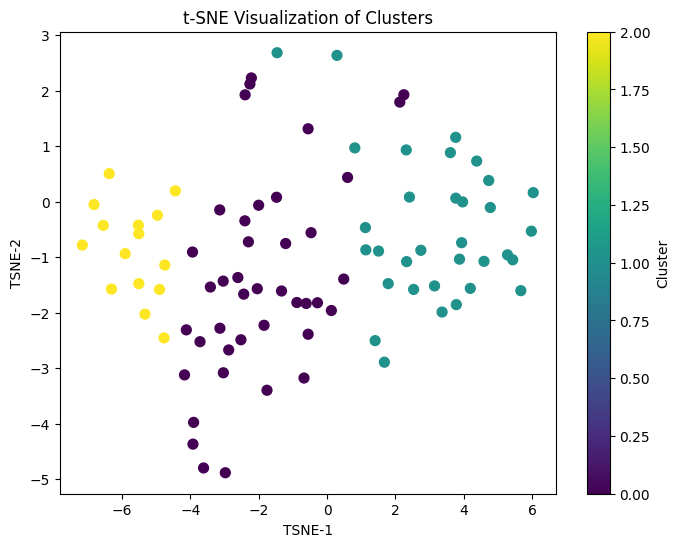

In [78]:
# Apply t-SNE for 2D projection

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(df_features)
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels, cmap='viridis', s=50)
plt.title('t-SNE Visualization of Clusters')
plt.xlabel('TSNE-1')
plt.ylabel('TSNE-2')
plt.colorbar(label='Cluster')
plt.show()
 

Cluster 0 (navy color):
* the points are compact inside the group
* it contains countries with average economy and touristic indexes

Cluster 1 ( light blue color)
* the points are quite spreaded out inside the group
* it contains countries with high economy but they have diverse touristic indexes

Cluster 2 (yellow color)
* the points are quite compact inside the group
* it contains countries with low economy and tourisic indexes.


In [79]:
#Cluster Evaluation
def dunn_index(X, labels):
    unique_cluster_labels = np.unique(labels)
    n_clusters = len(unique_cluster_labels)
    # Compute intra-cluster distances (max within each cluster)
    intra_dists = []
    for k in unique_cluster_labels:
        cluster_points = X[labels == k]
        if len(cluster_points) > 1:
            distances = pairwise_distances(cluster_points)
            intra_dists.append(np.max(distances))
        else:
            intra_dists.append(0)
 
    max_intra = np.max(intra_dists)
 
    # Compute inter-cluster distances (min between each pair of clusters)
    inter_dists = []
    for i in range(n_clusters):
        for j in range(i + 1, n_clusters):
            cluster_i = X[labels == unique_cluster_labels[i]]
            cluster_j = X[labels == unique_cluster_labels[j]]
            distances = pairwise_distances(cluster_i, cluster_j)
            inter_dists.append(np.min(distances))
 
    min_inter = np.min(inter_dists)
 
    return min_inter / max_intra if max_intra != 0 else 0
 
silhouette = silhouette_score(df_features, cluster_labels)
dunn = dunn_index(df_features, cluster_labels)
davies = davies_bouldin_score(df_features, cluster_labels)
calinski = calinski_harabasz_score(df_features, cluster_labels)
 
 
print(f"Silhouette Score: {silhouette:.4f}")
print(f"Dunn Index: {dunn:.4f}")
print(f"Davies-Bouldin Index: {davies:.4f}")
print(f"Calinski-Harabasz Index: {calinski:.4f}")

Silhouette Score: 0.1872
Dunn Index: 0.1291
Davies-Bouldin Index: 1.5272
Calinski-Harabasz Index: 26.6748


In [56]:
# Add labels back to data
clustered_df = pd.concat([country_info, pd.DataFrame(df_features), pd.Series(cluster_labels, name='Cluster')], axis=1)
clustered_df.to_csv('kmeans_3_clusters.csv')

# UPDATED K-MEANS (selected the features based on correlation matrix)

In [80]:
# Compute correlation matrix
correlation_matrix = df_features.corr()
  
# Identify features with correlation above a threshold (e.g., 0.85)
threshold = 0.85
to_remove = set()
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            colname = correlation_matrix.columns[i]
            to_remove.add(colname)
 
# Print final feature list
features_to_use = [col for col in df_features.columns if col not in to_remove]
print("Features to use for KMeans clustering (after removing highly correlated ones):")
for feature in features_to_use:
    print("-", feature)

Features to use for KMeans clustering (after removing highly correlated ones):
- TourismEmploymentPer1000
- TourismGDPPercentage
- BusinessToPersonalRatio
- AverageStayDays
- InboundArrivalsPer1000
- DomesticTouristsPer1000
- InboundToOutboundRatio
- QualityOfLifeIndex
- ReverseTrafficInefficiencyIndex
- CostOfLivingIndex
- SafetyIndex
- HealthCareIndex
- ClimateIndex


Best number of clusters based on Silhouette scores: 2
Best number of clusters based on Elbow method: 2


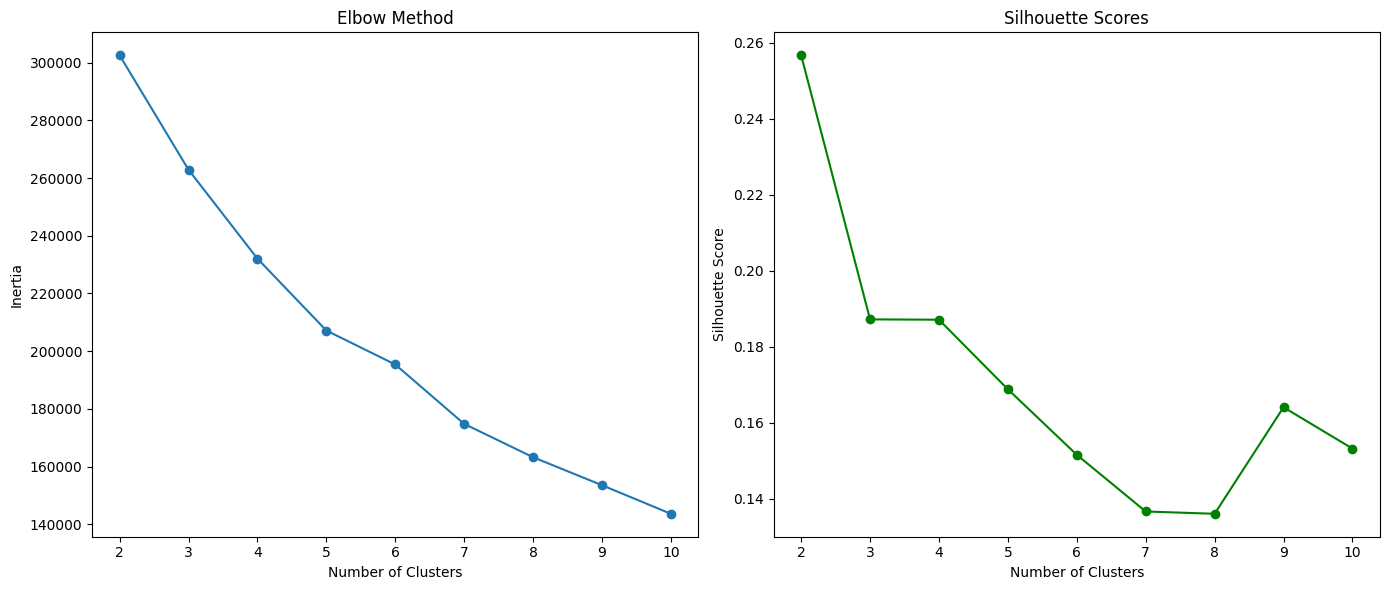

In [81]:
inertia = []
silhouette_scores = []
k_range = range(2, 11)
 
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_features)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_features, kmeans.labels_))
 
#Choose the best k (based on max silhouette score)
best_k = range_n_clusters[silhouette_scores.index(max(silhouette_scores))]
best_k_elbow = range_n_clusters[inertia.index(max(inertia))]
print(f"Best number of clusters based on Silhouette scores: {best_k}")
print(f"Best number of clusters based on Elbow method: {best_k_elbow}")
 
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
 
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o', color='green')
plt.title("Silhouette Scores")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
 
plt.tight_layout()
plt.show()

In [61]:
optimal_k = 2

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(df_features)
df_clustered = country_info.copy()
df_clustered["Cluster"] = labels
df_clustered_final = pd.concat([country_info, pd.Series(labels, name="Cluster")], axis=1)
cluster_counts = df_clustered_final['Cluster'].value_counts()
print("Number of countries in each cluster:")
print(cluster_counts)
 
#Group countries by cluster and display all
k2_grouped = df_clustered_final.groupby('Cluster')['CountryName'].apply(list).reset_index()
k2_grouped.columns = ['Cluster', 'Countries']
print("\nCountries grouped by cluster:")
for _, row in k2_grouped.iterrows():
    print(f"\nCluster {row['Cluster']} - {len(row['Countries'])} countries:")
    print(', '.join(row['Countries']))
 
 

 

Number of countries in each cluster:
Cluster
0    50
1    39
Name: count, dtype: int64

Countries grouped by cluster:

Cluster 0 - 50 countries:
Albania, Algeria, Angola, Argentina, Azerbaijan, Belarus, Belize, Brazil, Brunei, Cameroon, Chile, Costa Rica, Dominican Republic, Ecuador, Egypt, El Salvador, Georgia, Ghana, Honduras, India, Indonesia, Jordan, Kazakhstan, Kyrgyzstan, Lebanon, Madagascar, Malaysia, Mauritius, Mexico, Moldova, Mongolia, Morocco, Mozambique, Namibia, Nicaragua, Nigeria, Palestine, Panama, Paraguay, Philippines, Romania, Russia, Serbia, South Africa, Sri Lanka, Thailand, Turkey, Uganda, Uzbekistan, Zambia

Cluster 1 - 39 countries:
Australia, Austria, Bahrain, Belgium, Cayman Islands, Croatia, Cyprus, Denmark, Estonia, Finland, France, Germany, Greece, Hungary, Iceland, Israel, Japan, Latvia, Lithuania, Monaco, Montenegro, Netherlands, New Zealand, Norway, Poland, Portugal, Puerto Rico, Saudi Arabia, Slovakia, Slovenia, South Korea, Spain, Sweden, Switzerland, T

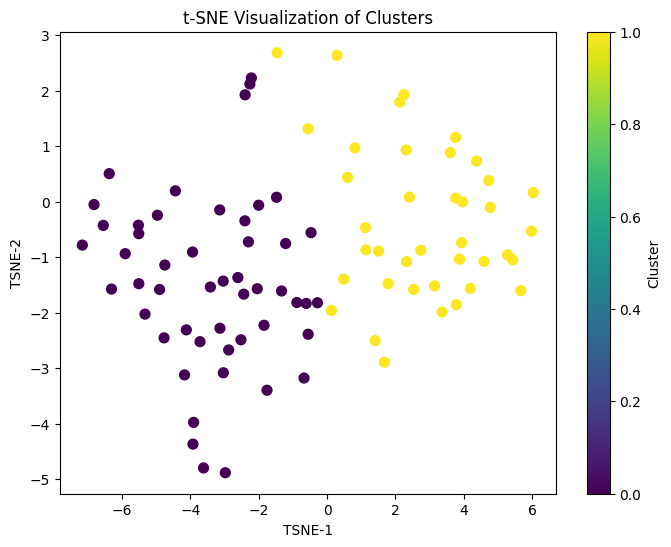

Silhouette Score: 0.2566448832778327
Dunn Index: 0.08970873670337037
Davies-Bouldin Index: 1.4332507828969032
Calinski-Harabasz Index: 35.478953796590794


In [83]:
# Apply t-SNE for 2D projection
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(df_features)
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='viridis', s=50)
plt.title('t-SNE Visualization of Clusters')
plt.xlabel('TSNE-1')
plt.ylabel('TSNE-2')
plt.colorbar(label='Cluster')
plt.show()
 
 
 
#Cluster Evaluation
def dunn_index(X, labels):
    unique_cluster_labels = np.unique(labels)
    n_clusters = len(unique_cluster_labels)

    # Compute intra-cluster distances (max within each cluster)
    intra_dists = []

    for k in unique_cluster_labels:
        cluster_points = X[labels == k]
        if len(cluster_points) > 1:
            distances = pairwise_distances(cluster_points)
            intra_dists.append(np.max(distances))
        else:
            intra_dists.append(0)
 
    max_intra = np.max(intra_dists)
    # Compute inter-cluster distances (min between each pair of clusters)
    inter_dists = []
    for i in range(n_clusters):
        for j in range(i + 1, n_clusters):
            cluster_i = X[labels == unique_cluster_labels[i]]
            cluster_j = X[labels == unique_cluster_labels[j]]
            distances = pairwise_distances(cluster_i, cluster_j)
            inter_dists.append(np.min(distances))
 
    min_inter = np.min(inter_dists)
    return min_inter / max_intra if max_intra != 0 else 0

print("Silhouette Score:", silhouette_score(df_features, labels))
print("Dunn Index:", dunn_index(df_features, labels))
print("Davies-Bouldin Index:", davies_bouldin_score(df_features, labels))
print("Calinski-Harabasz Index:", calinski_harabasz_score(df_features, labels))
 

Based on the t-SNE visualization the cluster 0 (navy color) contains countries with poor economy and quite bad touristic index while the cluster 1 (yellow color) has countries with better economy and touristic indexes.